In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt

from src.analysis import stochastic_bivariate_simulation
from src.config import variable_names
from src.core import Variable
from src.models import NetIncomeModel, MarketPriceModel
from src.variables import Cost, PriceToEarningsRatio
from src.visualization import generate_linear_regression_from_lists

In [2]:
variables = {
    variable_names.REVENUE: Variable(min=80000.0, exp=100000.0, max=120000.0),
    variable_names.COST: Cost(min=30000.0, exp=40000.0, max=50000.0),
    variable_names.PE_RATIO: PriceToEarningsRatio(min=5.0, exp=8.0, max=10.0)
}

pipeline = [NetIncomeModel(), MarketPriceModel()]

In [3]:
simulated_x, simulated_y, stats = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.REVENUE,
    dependent_target_y=variable_names.MARKET_PRICE,
    shuffled_variables=[variable_names.REVENUE],
    model_pipeline=pipeline,
    sample_size=100
)

print(stats)

{'slope': 95.99999999999996, 'intercept': -3839999.999999998, 'r_squared': 0.9999999999999998, 'p_value': 0.0, 'standard_error': 1.445034806087795e-07}


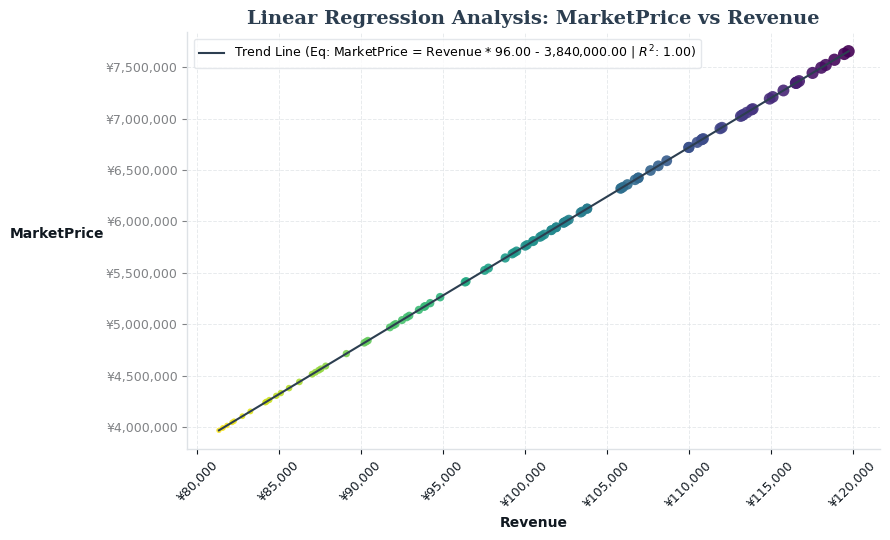

In [4]:
fig = generate_linear_regression_from_lists(simulated_x, simulated_y,
                                            variable_names.REVENUE, variable_names.MARKET_PRICE)
plt.show()

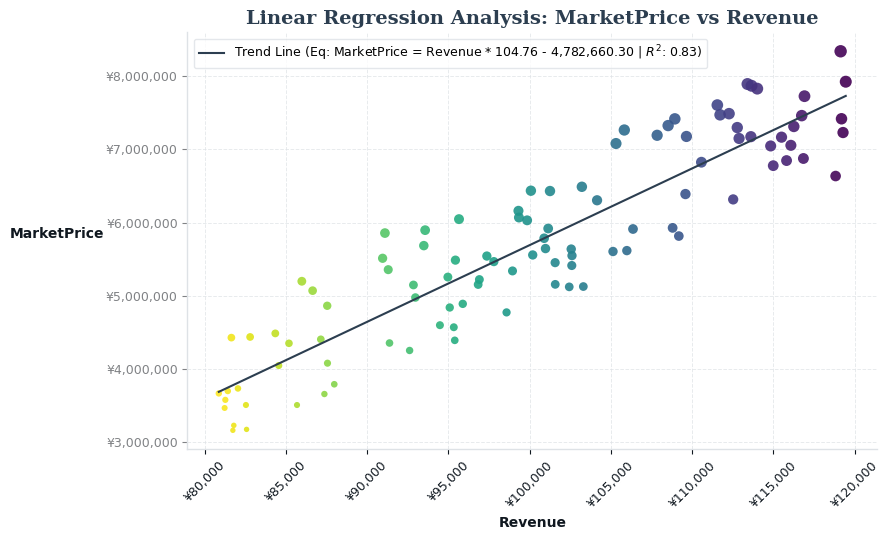

In [5]:
simulated_x, simulated_y, stats = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.REVENUE,
    dependent_target_y=variable_names.MARKET_PRICE,
    shuffled_variables=[variable_names.REVENUE, variable_names.COST],
    model_pipeline=pipeline,
    sample_size=100
)

fig = generate_linear_regression_from_lists(simulated_x, simulated_y,
                                            variable_names.REVENUE, variable_names.MARKET_PRICE)
plt.show()

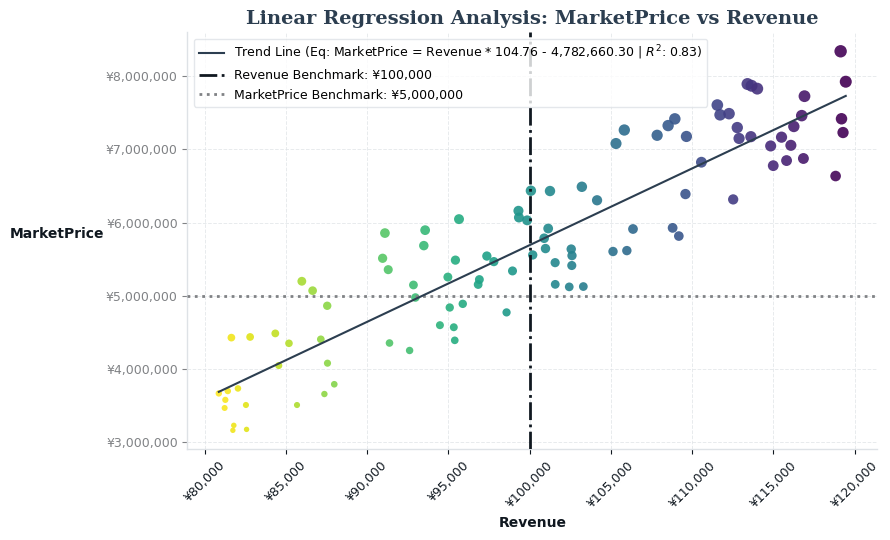

In [6]:
fig = generate_linear_regression_from_lists(simulated_x, simulated_y,
                                            variable_names.REVENUE, variable_names.MARKET_PRICE,
                                            x_benchmark=100000, y_benchmark=5000000)
plt.show()

In [7]:
plt.close()